# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Anggun Sulis Setyawan
- Email: sul191120@gmail.com
- Id Dicoding: sulbae

## Persiapan

### Menyiapkan library yang dibutuhkan

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib

from sqlalchemy import create_engine 

### Menyiapkan data yang akan diguankan

## Data Understanding

### Load Data

In [ ]:
df = pd.read_csv('https://raw.githubusercontent.com/Sulbae/HR-Dashboard/refs/heads/main/employee_data.csv')

df.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

Keterangan:
| # | Column | Non-Null Count | Dtype | Description |
|---|--------|--------------|-----|---|  
| 0 |  EmployeeId              | 1470 non-null |  int64 | Employee identifier |
| 1 |  Age                     | 1470 non-null |  int64 | Age of the employee  |
| 2 | Attrition                | 1058 non-null |  float64 | Did the employee atrition? (0=no, 1=yes) |
| 3 | BusinessTravel           | 1470 non-null |  object | Travel commitments for the job |
| 4 | DailyRate                | 1470 non-null |  int64 | Daily salary |
| 5 | Department               | 1470 non-null |  object | Employee Department |
| 6 | DistanceFromHome         | 1470 non-null |  int64 | Distance from work to home (in km) |
| 7 | Education                | 1470 non-null |  int64 | (1=Below College, 2=College, 3=Bachelor, 4=Master, 5=Doctor) |
| 8 | EducationField           | 1470 non-null |  object | Field of Education |
| 9 | EmployeeCount            | 1470 non-null |  int64 |  |
| 10 | EnvironmentSatisfaction  | 1470 non-null |  int64 | (1=Low, 2=Medium, 3=High, 4=Very High) |
| 11 | Gender                   | 1470 non-null |  object | Employee's Gender |
| 12 | HourlyRate               | 1470 non-null |  int64 | Hourly salary |
| 13 | JobInvolvement           | 1470 non-null |  int64 | (1=Low, 2=Medium, 3=High, 4=Very High) |
| 14 | JobLevel                 | 1470 non-null |  int64 | Level of job (1 to 5) |
| 15 | JobRole                  | 1470 non-null |  object | Job Roles |
| 16 | JobSatisfaction          | 1470 non-null |  int64 | (1=Low, 2=Medium, 3=High, 4=Very High) |
| 17 | MaritalStatus            | 1470 non-null |  object | Marital Status |
| 18 | MonthlyIncome            | 1470 non-null |  int64 | Monthly Salary |
| 19 | MonthlyRate              | 1470 non-null |  int64 | Monthly Rate |
| 20 | NumCompaniesWorked       | 1470 non-null |  int64 | Number of companies worked at |
| 21 | Over18                   | 1470 non-null |  object | Over 18 years of age? |
| 22 | OverTime                 | 1470 non-null |  object | Overtime? |
| 23 | PercentSalaryHike        | 1470 non-null |  int64 | The percentage increase in salary last year |
| 24 | PerformanceRating        | 1470 non-null |  int64 | (1=Low, 2=Good, 3=Excellent, 4=Outstanding) |
| 25 | RelationshipSatisfaction | 1470 non-null |  int64 | (1=Low, 2=Medium, 3=High, 4=Very High) |
| 26 | StandardHours            | 1470 non-null |  int64 | Standard Hours |
| 27 | StockOptionLevel         | 1470 non-null |  int64 | Stock Option Level |
| 28 | TotalWorkingYears        | 1470 non-null |  int64 | Total years worked |
| 29 | TrainingTimesLastYear    | 1470 non-null |  int64 | Number of training attended last year |
| 30 | WorkLifeBalance          | 1470 non-null |  int64 | (1=Low, 2=Good, 3=Excellent, 4=Outstanding) |
| 31 | YearsAtCompany           | 1470 non-null |  int64 | Years at Company |
| 32 | YearsInCurrentRole       | 1470 non-null |  int64 | Years in current role |
| 33 | YearsSinceLastPromotion  | 1470 non-null |  int64 | Years since the last promotion |
| 34 | YearsWithCurrManager     | 1470 non-null |  int64 | Years with the current manager |

In [7]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
EmployeeId,1470.0,NaN,NaN,NaN,735.5,424.496761,1.0,368.25,735.5,1102.75,1470.0
Age,1470.0,NaN,NaN,NaN,36.92381,9.135373,18.0,30.0,36.0,43.0,60.0
Attrition,1058.0,NaN,NaN,NaN,0.169187,0.375094,0.0,0.0,0.0,0.0,1.0
BusinessTravel,1470,3,Travel_Rarely,1043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DailyRate,1470.0,NaN,NaN,NaN,802.485714,403.5091,102.0,465.0,802.0,1157.0,1499.0
Department,1470,3,Research & Development,961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,1470.0,NaN,NaN,NaN,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
Education,1470.0,NaN,NaN,NaN,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
EducationField,1470,6,Life Sciences,606,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,1470.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0


### Raw Data Exploration

#### Cek Kelengkapan Data

In [10]:
print('Missing values:\n', df.isnull().sum())

print('Duplicate values:', df.duplicated().sum())

Missing values:
 EmployeeId                    0
Age                           0
Attrition                   412
BusinessTravel                0
DailyRate                     0
Department                    0
DistanceFromHome              0
Education                     0
EducationField                0
EmployeeCount                 0
EnvironmentSatisfaction       0
Gender                        0
HourlyRate                    0
JobInvolvement                0
JobLevel                      0
JobRole                       0
JobSatisfaction               0
MaritalStatus                 0
MonthlyIncome                 0
MonthlyRate                   0
NumCompaniesWorked            0
Over18                        0
OverTime                      0
PercentSalaryHike             0
PerformanceRating             0
RelationshipSatisfaction      0
StandardHours                 0
StockOptionLevel              0
TotalWorkingYears             0
TrainingTimesLastYear         0
WorkLifeBalance        

_Insight:_
- Terdapat **412** data dari kolom **Attrition** yang kosong. Kolom Attrition merupakan kolom target dari analisis yang akan dilakukan. Oleh karena itu, data yang kosong sebaiknya dieliminasi dari proses analisis kali ini.
- Diketahui bahwa tidak terdapat baris data yang duplikat.

#### Cek Distribusi Data

##### Kolom Numerik

In [14]:
# numerical features
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns

print('Numerical features:\n', numerical_features)

Numerical features:
 Index(['EmployeeId', 'Age', 'Attrition', 'DailyRate', 'DistanceFromHome',
       'Education', 'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')


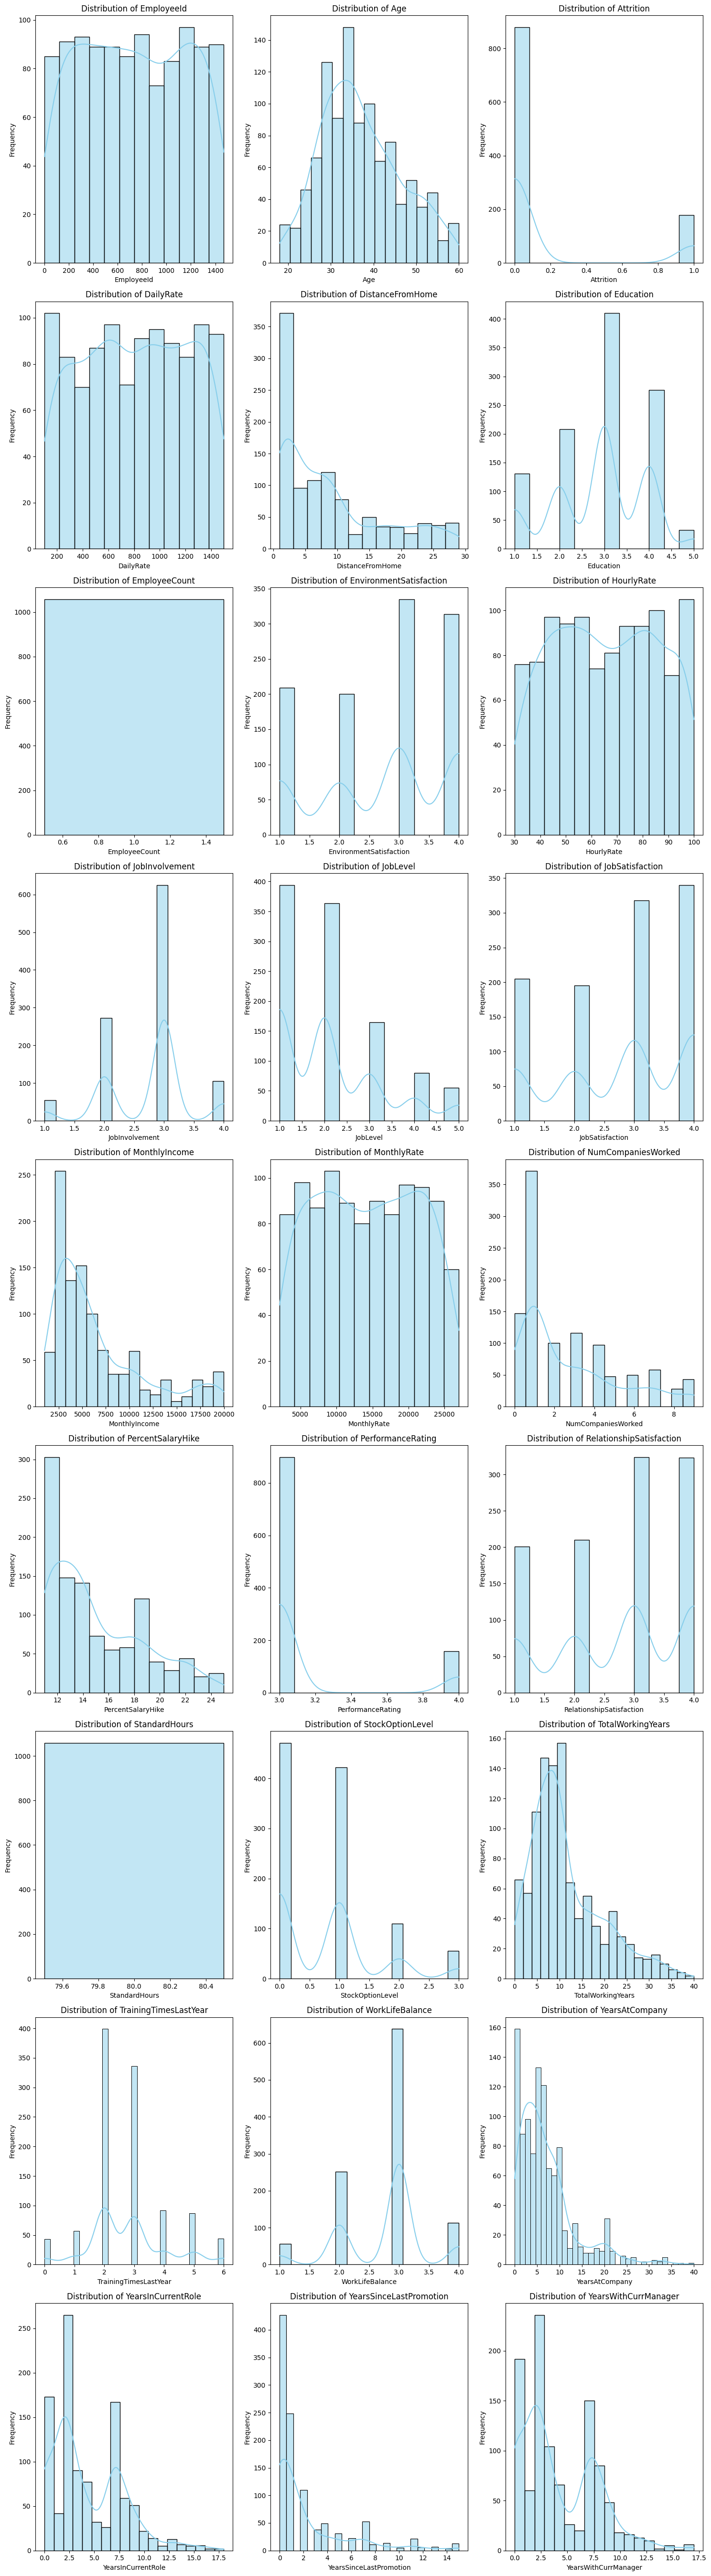

In [38]:
# histogram
n_cols = len(numerical_features)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 6 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

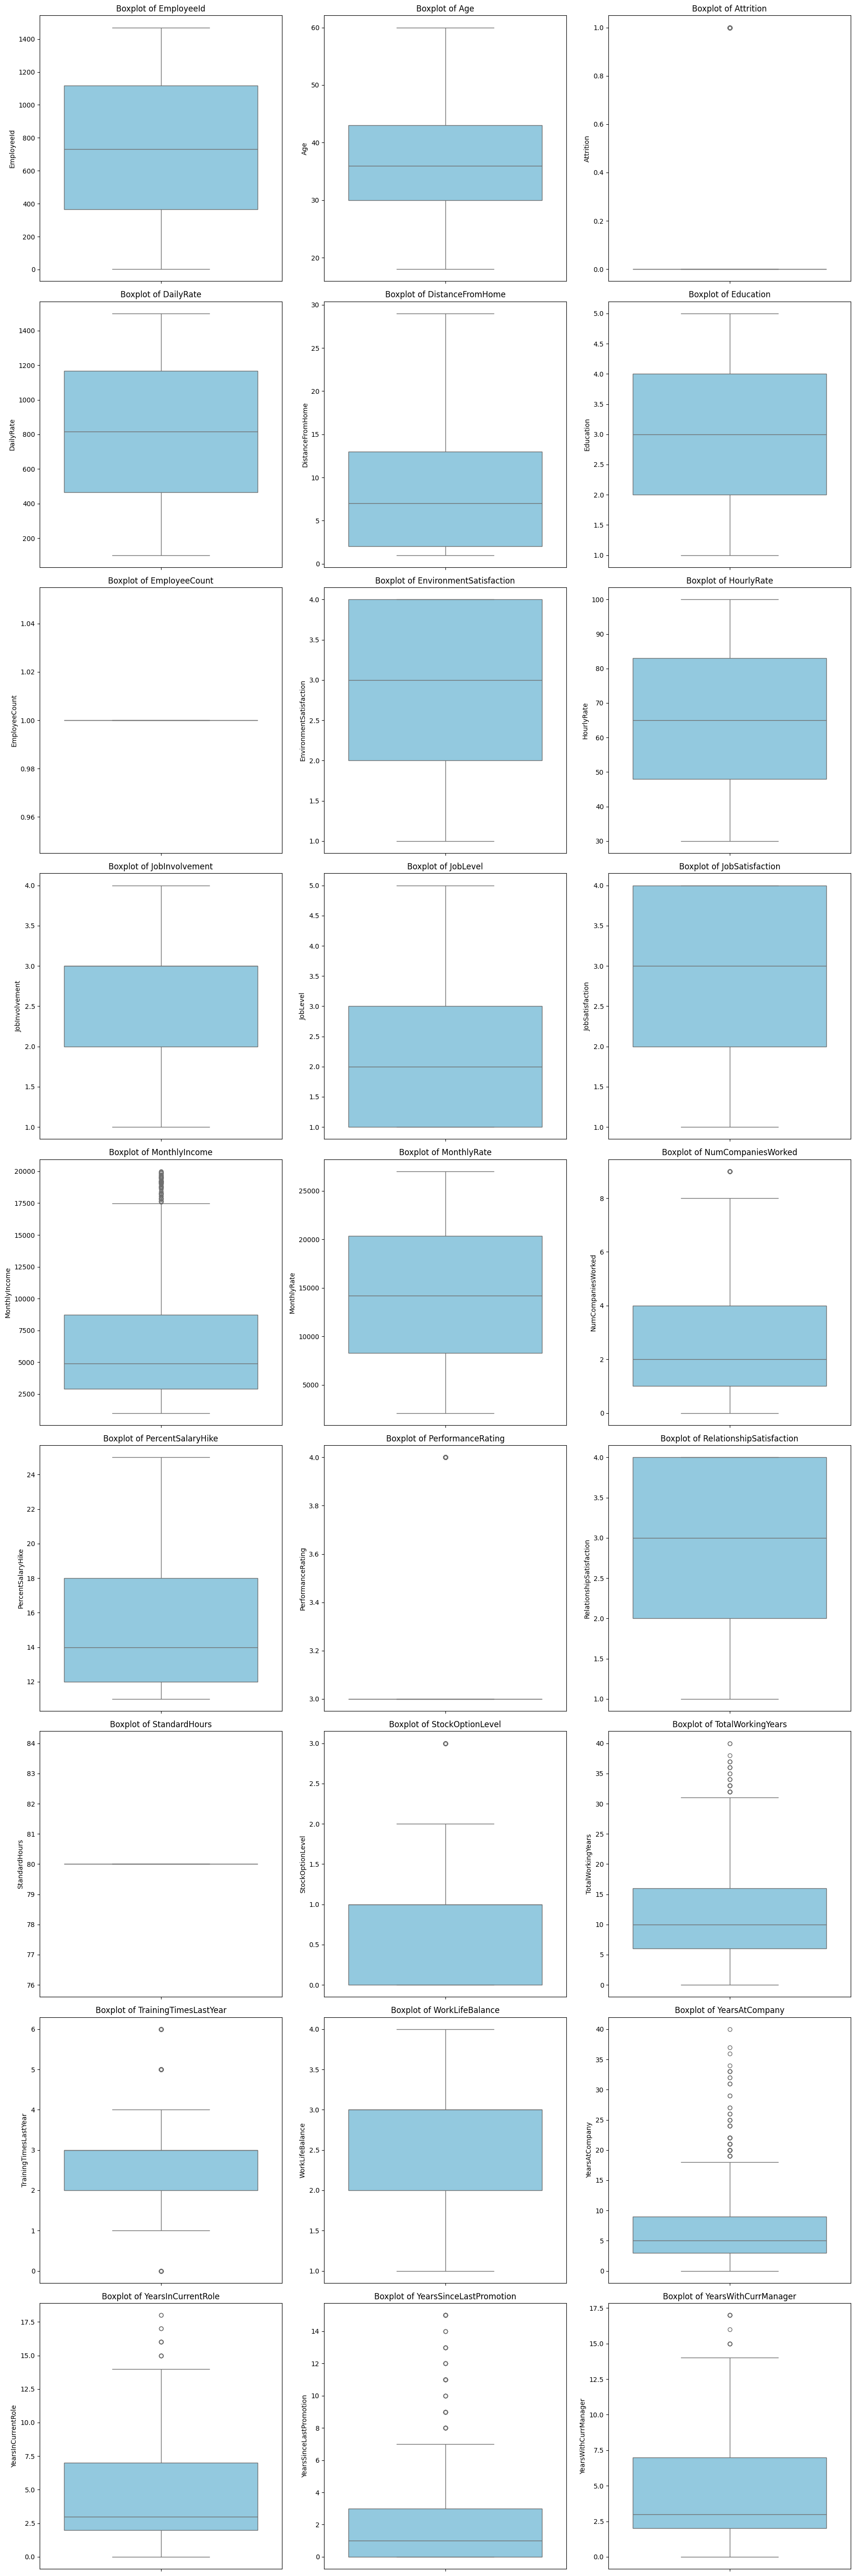

In [35]:
# Periksa outlier
n_cols = len(numerical_features)
n_rows = (n_cols + 2) // 3

fig, axes = plt.subplots(n_rows, 3, figsize=(18, 6 * n_rows))
axes = axes.flatten()

for idx, col in enumerate(numerical_features):
    sns.boxplot(data=df[col], ax=axes[idx], color='skyblue')
    axes[idx].set_title(f'Boxplot of {col}')
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel(col)

plt.tight_layout()
plt.show()

##### Kolom Kategorikal

In [15]:
# categorical features
categorical_features = df.select_dtypes(include=['object']).columns

print('Categorical features:\n', categorical_features)

Categorical features:
 Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


C:\Users\ACER\AppData\Local\Temp\ipykernel_28272\3082400699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes_cat[idx], palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_28272\3082400699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes_cat[idx], palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_28272\3082400699.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes_cat[idx], palette='Set2')
C:\Users\ACER\AppData\Local\Temp\ipykernel_28272\308240

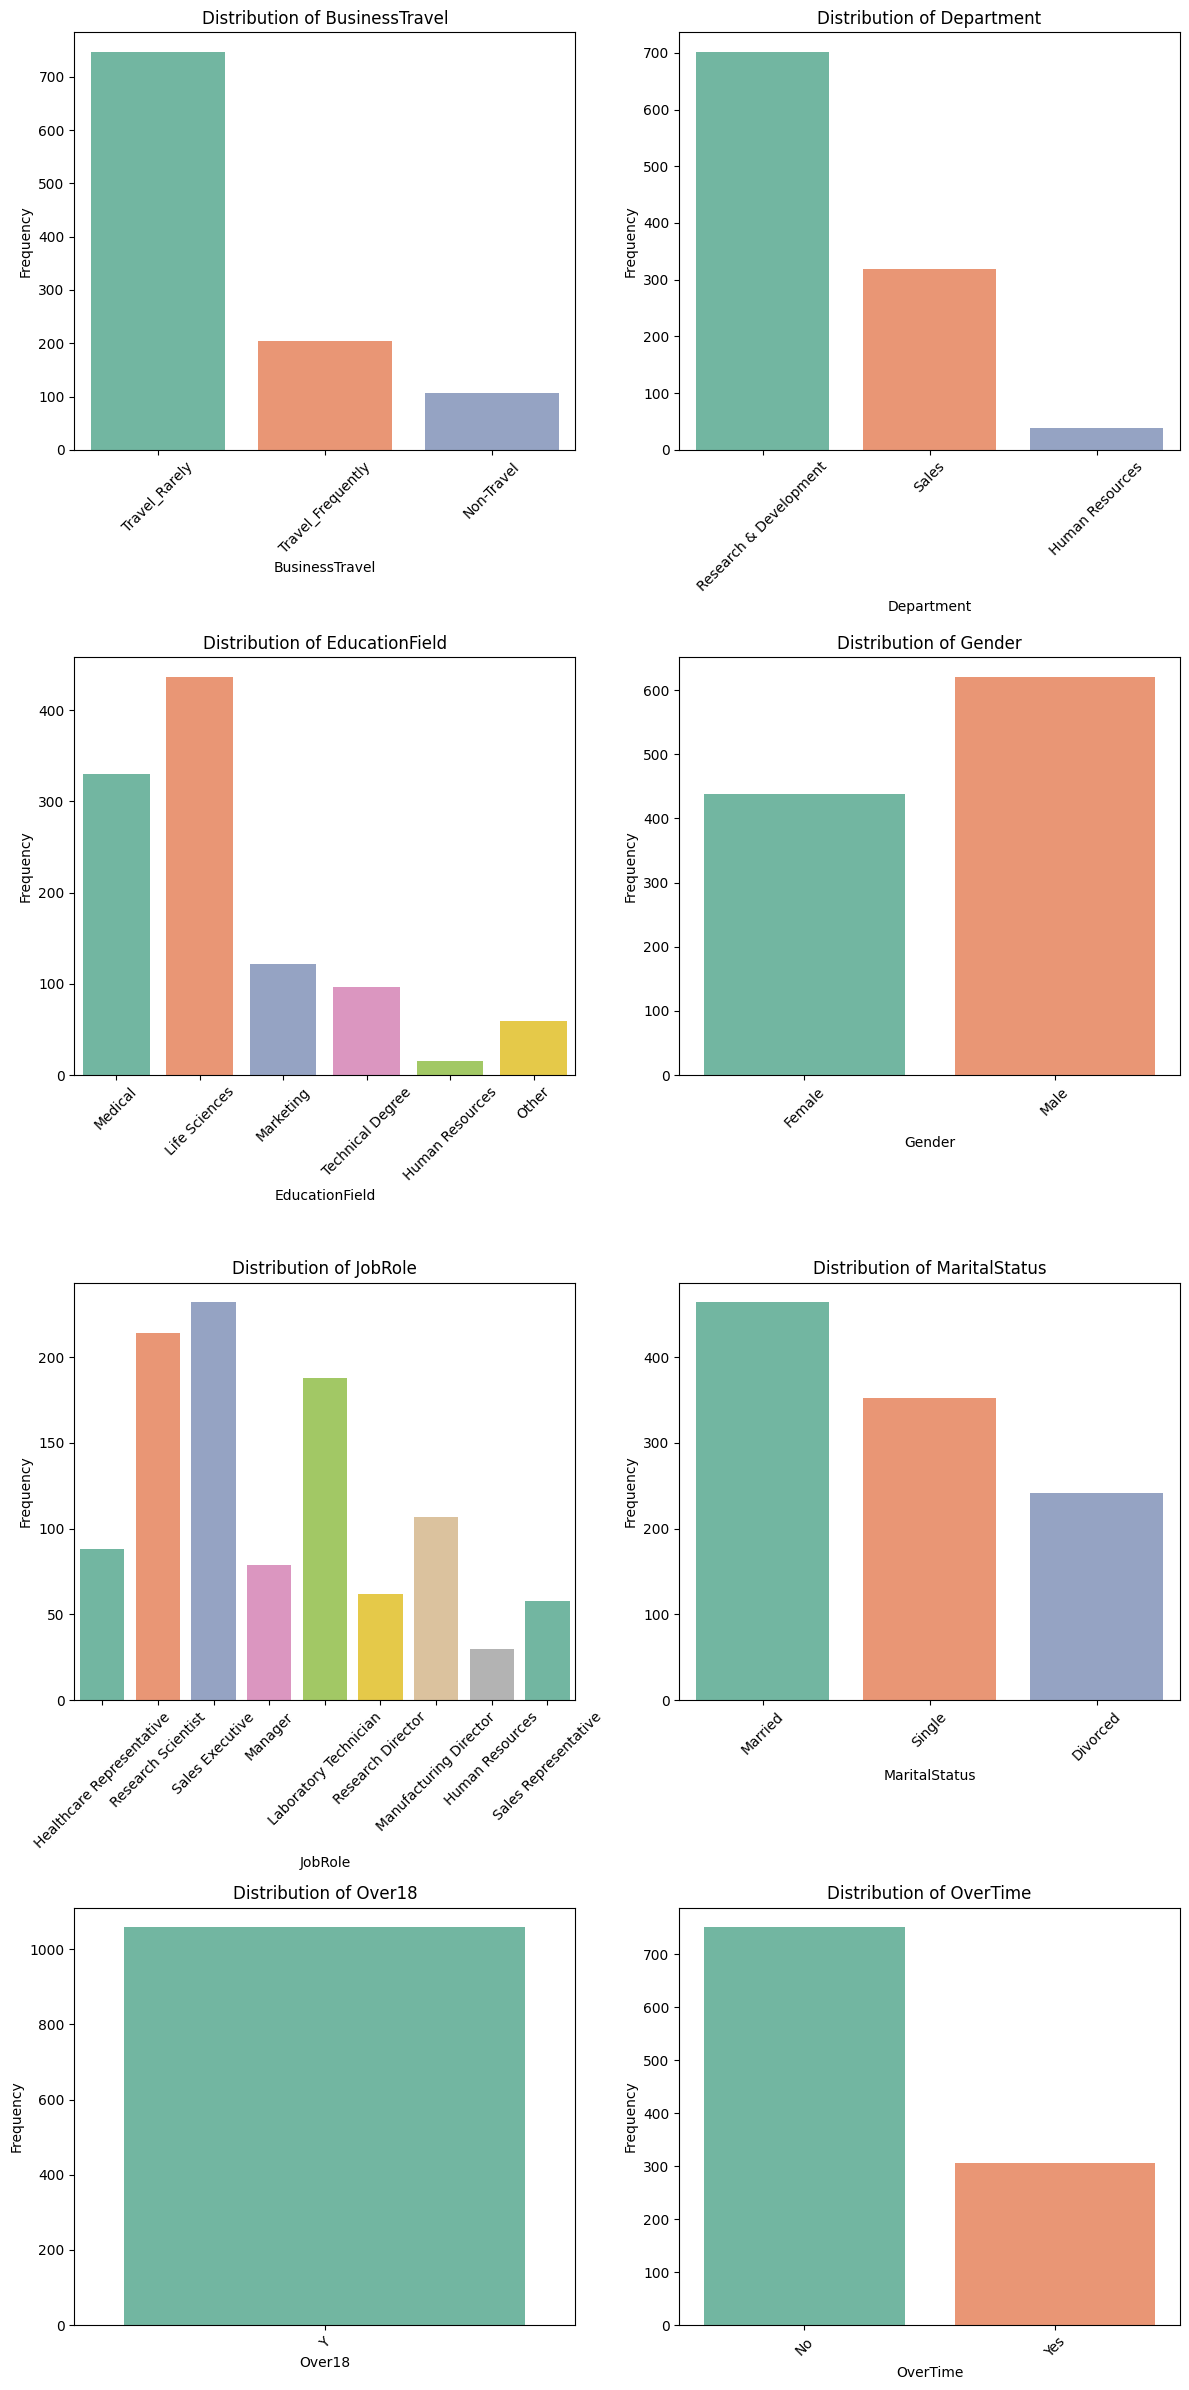

In [37]:
# countplot
cat_cols = len(categorical_features)
cat_rows = (cat_cols + 1) // 2

fig_cat, axes_cat = plt.subplots(cat_rows, 2, figsize=(12, 6 * cat_rows))
axes_cat = axes_cat.flatten()

for idx, col in enumerate(categorical_features):
    sns.countplot(data=df, x=col, ax=axes_cat[idx], palette='Set2')
    axes_cat[idx].set_title(f'Distribution of {col}')
    axes_cat[idx].set_xlabel(col)
    axes_cat[idx].set_ylabel('Frequency')
    axes_cat[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Data Preparation / Preprocessing

#### Missing Values Handling

In [12]:
# Missing values handling
df.dropna(inplace=True)

print('Missing values after handling:\n', df.isnull().sum().sum())

Missing values after handling:
 0


#### Standardization

#### Encoding

#### Data Exploration After Preprocessing

##### Cek Korelasi Data

#### Data Split

In [ ]:
x = df.drop('Attrition', axis=1)
y = df['Attrition']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

## Modeling

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_leaf=1,
    min_samples_split=2,
    random_state=42
)

In [ ]:
model.fit(X_train, y_train)

## Evaluation

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(classification_report(y_test, y_pred))

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

In [ ]:
# feature importance
feature_importance_df = pd.DataFrame({
    'feature': x.columns,
    'importance': model.feature_importances_
}).sort_values(by='importance', ascending=False)

feature_importance_df.head()

In [ ]:
# save model
joblib.dump(model, 'model.pkl')